### 사전 설정

In [1]:
# 🔹 1. 나눔글꼴 설치 -> 이거 실행하고 런타임 초기화 한 이후에 아래 셀부터 다시 진행
!apt-get update -qq
!apt-get install -y fonts-nanum fonts-nanum-extra fonts-nanum-coding

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum fonts-nanum-coding fonts-nanum-extra
0 upgraded, 3 newly installed, 0 to remove and 44 not upgraded.
Need to get 31.4 MB of archives.
After this operation, 120 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-coding all 2.5-3 [4,988 B]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum-extra all 20200506-1 [21.0 MB]
Fetched 31.4 MB in 2s (13.8 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 126111 files and directories currently insta

In [1]:
import os
import matplotlib as mpl

# 폰트 캐시 파일 제거
font_cache_dir = os.path.expanduser('~/.cache/matplotlib')
if os.path.exists(font_cache_dir):
    import shutil
    shutil.rmtree(font_cache_dir)
    print("폰트 캐시 삭제 완료")
else:
    print("폰트 캐시 없음")

폰트 캐시 삭제 완료


In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

mpl.rcParams['font.family'] = 'NanumGothic'
mpl.rcParams['axes.unicode_minus'] = False

['NanumGothic']


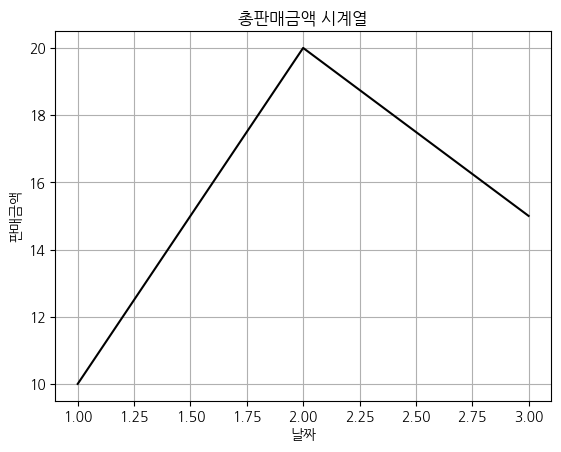

In [3]:
print(mpl.rcParams['font.family'])

plt.plot([1, 2, 3], [10, 20, 15], color='black')
plt.title('총판매금액 시계열')  # <- 여기가 깨지면 폰트 설정 실패
plt.xlabel('날짜')
plt.ylabel('판매금액')
plt.grid(True)
plt.show()

### 데이터 불러오기 & 전처리

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import pandas as pd
import numpy as np

'''전처리 과정 참고 (생략)
file_path = '/content/drive/MyDrive/경경데/rawdata.csv'
sale = pd.read_csv(file_path, encoding = 'utf-8')

sale = sale[['회차','추첨일자','총판매금액','1등 당첨게임 수','1등 1게임당 당첨금액','이월여부', '4등 당첨게임 수', '5등 당첨게임 수']]
sale['fourth_fifth_num'] = sale['4등 당첨게임 수'] + sale['5등 당첨게임 수']
sale['fourth_fifth_num'] = sale['fourth_fifth_num'].astype(str).str.replace(',', '').astype(int)
sale['추첨일자'] = pd.to_datetime(sale['추첨일자'])
sale['1등 1게임당 당첨금액'] = sale['1등 1게임당 당첨금액'].astype(str).str.replace(',', '').astype(int)
sale = sale.sort_values(by='추첨일자')
sale.rename(columns = {"추첨일자": "date", "총판매금액":"total_sale","회차":"round","1등 당첨게임 수":"first_num","1등 1게임당 당첨금액":"first_amount","이월여부":"carry_over"}, inplace=True)'''



# 데이터 불러오기
rawdata = pd.read_csv('/content/drive/MyDrive/경경데/rawdata.csv', encoding = 'utf-8')
sale_df = pd.read_csv('/content/drive/MyDrive/경경데/final_cf_sales.csv')
economy_df = pd.read_csv("/content/drive/MyDrive/경경데/CCSI.csv", encoding = 'utf-8')

# 추가 전처리 (필요없는 컬럼 삭제 및 컬럼명 변경)
sale_df.drop(['cf_total_sale', '4등 당첨게임 수', '5등 당첨게임 수'], axis=1, inplace=True)
sale_df["log_cf_total_sale"] = np.log(sale_df['cf_total_sale_adjusted'])
sale_df.rename(columns= {'cf_total_sale_adjusted' : 'cf_total_sale'}, inplace=True)
print(sale_df.info())

# 날짜 형식 변환
rawdata['추첨일자'] = pd.to_datetime(rawdata['추첨일자'])
economy_df['date'] = pd.to_datetime(economy_df['date'], format='%Y/%m')
sale_df["date"] = pd.to_datetime(sale_df["date"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911 entries, 0 to 910
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               911 non-null    object 
 1   round              911 non-null    float64
 2   total_sale         911 non-null    float64
 3   first_num          911 non-null    float64
 4   first_amount       911 non-null    int64  
 5   carry_over         911 non-null    float64
 6   fourth_fifth_num   911 non-null    int64  
 7   log_total_sale     911 non-null    float64
 8   cf_total_sale      911 non-null    float64
 9   log_cf_total_sale  911 non-null    float64
dtypes: float64(7), int64(2), object(1)
memory usage: 71.3+ KB
None


In [12]:
# 데이터 머지

# 1. datetime 형식으로 변환 (혹시 안됐을 경우 대비)
sale_df['date'] = pd.to_datetime(sale_df['date'])
economy_df['date'] = pd.to_datetime(economy_df['date'])

# 2. 'year-month' 단위로 통일 (sale_df에 'year_month' 컬럼 생성)
sale_df['year_month'] = sale_df['date'].dt.to_period('M').astype(str)
economy_df['year_month'] = economy_df['date'].dt.to_period('M').astype(str)

# 3. 머지 수행 (left join으로 sale_df 기준)
sale = sale_df.merge(economy_df[['year_month', 'CCSI']], on='year_month', how='left')

In [13]:
sale.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911 entries, 0 to 910
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               911 non-null    datetime64[ns]
 1   round              911 non-null    float64       
 2   total_sale         911 non-null    float64       
 3   first_num          911 non-null    float64       
 4   first_amount       911 non-null    int64         
 5   carry_over         911 non-null    float64       
 6   fourth_fifth_num   911 non-null    int64         
 7   log_total_sale     911 non-null    float64       
 8   cf_total_sale      911 non-null    float64       
 9   log_cf_total_sale  911 non-null    float64       
 10  year_month         911 non-null    object        
 11  CCSI               882 non-null    float64       
dtypes: datetime64[ns](1), float64(8), int64(2), object(1)
memory usage: 85.5+ KB


In [14]:
# 2008년부터의 데이터셋 (CCSI가 있는 경우만)
sale_copy = sale.copy()
sale_2008 = sale_copy[sale_copy['CCSI'].notnull()]
print(sale_2008.info())

<class 'pandas.core.frame.DataFrame'>
Index: 882 entries, 29 to 910
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               882 non-null    datetime64[ns]
 1   round              882 non-null    float64       
 2   total_sale         882 non-null    float64       
 3   first_num          882 non-null    float64       
 4   first_amount       882 non-null    int64         
 5   carry_over         882 non-null    float64       
 6   fourth_fifth_num   882 non-null    int64         
 7   log_total_sale     882 non-null    float64       
 8   cf_total_sale      882 non-null    float64       
 9   log_cf_total_sale  882 non-null    float64       
 10  year_month         882 non-null    object        
 11  CCSI               882 non-null    float64       
dtypes: datetime64[ns](1), float64(8), int64(2), object(1)
memory usage: 89.6+ KB
None


### 기본 시계열 차트

In [15]:
rawdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1173 entries, 0 to 1172
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   연도            1173 non-null   int64         
 1   회차            1173 non-null   int64         
 2   추첨일자          1173 non-null   datetime64[ns]
 3   1등 당첨게임 수     1173 non-null   int64         
 4   1등 1게임당 당첨금액  1173 non-null   object        
 5   2등 당첨게임 수     1173 non-null   int64         
 6   2등 1게임당 당첨금액  1173 non-null   object        
 7   3등 당첨게임 수     1173 non-null   object        
 8   3등 1게임당 당첨금액  1173 non-null   object        
 9   4등 당첨게임 수     1173 non-null   object        
 10  4등 1게임당 당첨금액  1173 non-null   object        
 11  5등 당첨게임 수     1173 non-null   object        
 12  5등 1게임당 당첨금액  1173 non-null   object        
 13  1             1173 non-null   int64         
 14  2             1173 non-null   int64         
 15  3             1173 non-null   int64   

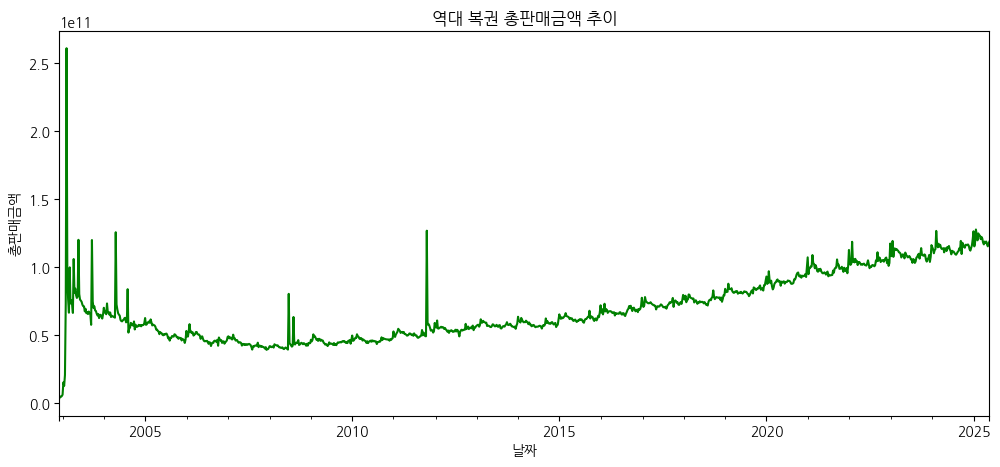

In [16]:
# 시계열 플롯
rawdata = rawdata.set_index('추첨일자')
rawdata['총판매금액'].plot(title='역대 복권 총판매금액 추이', figsize=(12, 5), color = 'green')
plt.xlabel('날짜')
plt.ylabel('총판매금액')

# 저장
plt.savefig('/content/drive/MyDrive/경경데/역대 복권 총판매금액 추이(2002~).png', dpi=300, bbox_inches='tight')
plt.show()

Index(['date', 'round', 'total_sale', 'first_num', 'first_amount',
       'carry_over', 'fourth_fifth_num', 'log_total_sale', 'cf_total_sale',
       'log_cf_total_sale', 'year_month', 'CCSI'],
      dtype='object')


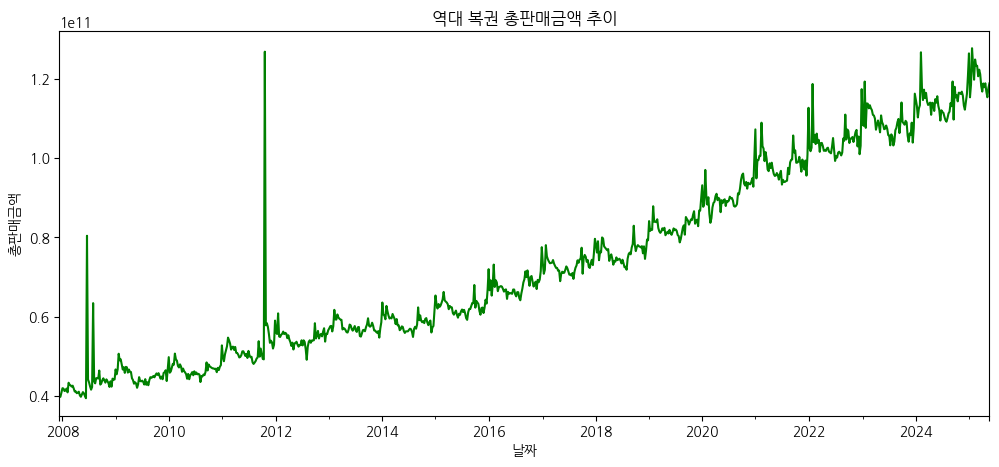

In [14]:
# 시계열 플롯
print(sale.columns)
sale = sale.set_index('date')
sale['total_sale'].plot(title='역대 복권 총판매금액 추이', figsize=(12, 5), color = 'green')
plt.xlabel('날짜')
plt.ylabel('총판매금액')

# 저장
plt.savefig('/content/drive/MyDrive/경경데/역대 복권 총판매금액 추이.png', dpi=300, bbox_inches='tight')
plt.show()

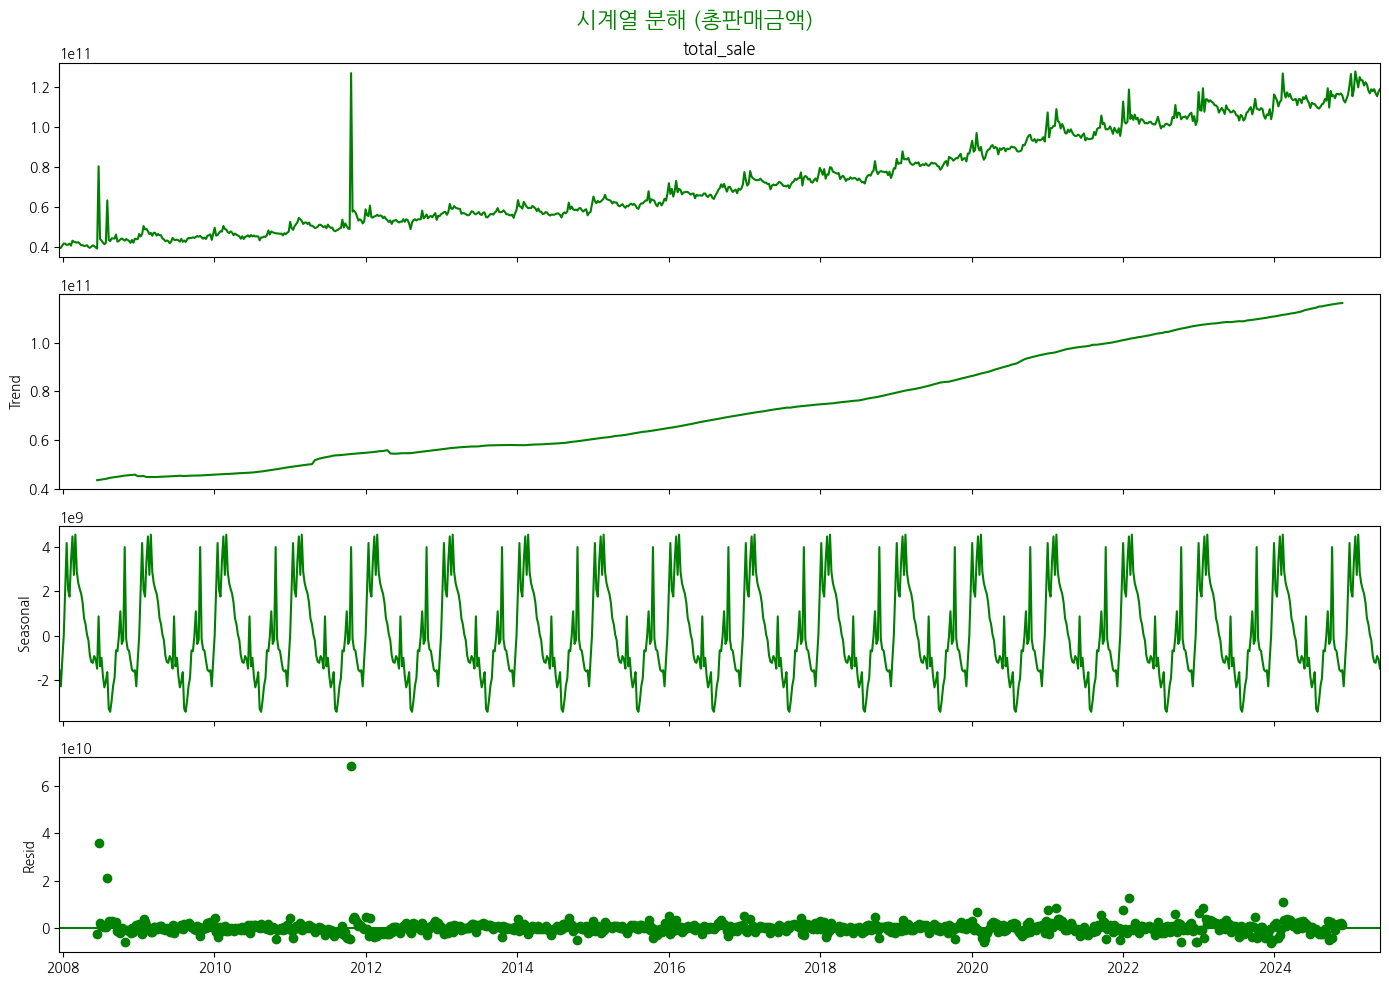

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import numpy as np

# 시계열 분해 (주간 데이터 기준)
decomposition = seasonal_decompose(sale['total_sale'], model='additive', period=52)

# 시각화
fig = decomposition.plot()
fig.set_size_inches(14, 10)

# 각 서브플롯의 선을 초록색으로 설정
for ax in fig.axes:
    for line in ax.lines:
        line.set_color('green')

plt.suptitle('시계열 분해 (총판매금액)', fontsize=16, color='green')
plt.tight_layout()

# 저장
plt.savefig('/content/drive/MyDrive/경경데/시계열 분해.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
# trend 시계열에서 최솟값 위치
trend = decomposition.trend.dropna()  # NaN 제외 (양 끝에 존재할 수 있음)

# 최솟값 인덱스(날짜)와 값 출력
min_date = trend.idxmin()
min_value = trend.min()

print(f"✅ 추세 최솟값 시점: {min_date}")
print(f"📉 최소 추세값: {min_value:,.0f}")

✅ 추세 최솟값 시점: 2008-06-14 00:00:00
📉 최소 추세값: 43,426,446,058


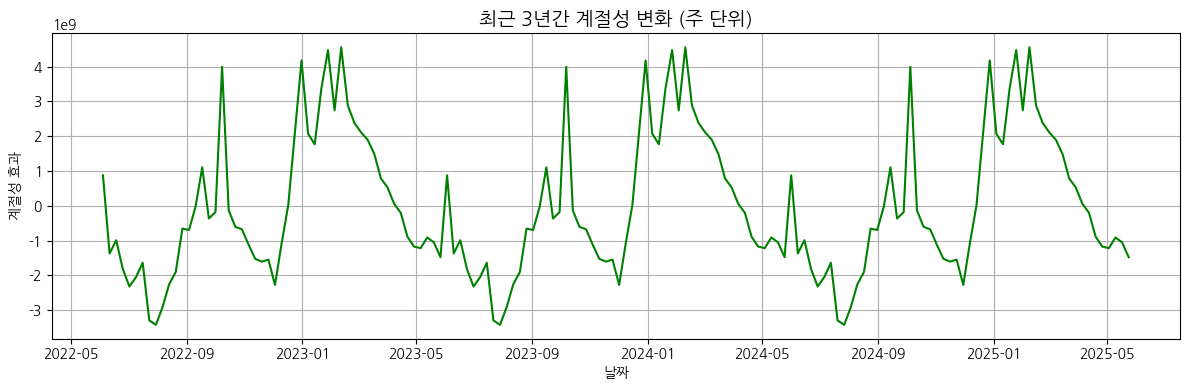

In [18]:
# seasonal 성분만 추출
seasonal = decomposition.seasonal

# 최근 3~4년치만 확대해서 보기 (가독성 향상)
seasonal_tail = seasonal[-156:]  # 52주 * 3년

plt.figure(figsize=(12, 4))
plt.plot(seasonal_tail, color='green')
plt.title('최근 3년간 계절성 변화 (주 단위)', fontsize=14)
plt.xlabel('날짜')
plt.ylabel('계절성 효과')
plt.grid(True)
plt.tight_layout()

# 저장
plt.savefig('/content/drive/MyDrive/경경데/계절성_최근3년.png', dpi=300, bbox_inches='tight')
plt.show()

### 정상성 검정 + ACF,PACF 검정

In [19]:
# ADF 검정
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

result = adfuller(sale['total_sale'].dropna())
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: 0.3566683399075325
p-value: 0.9798001346057171


In [20]:
# p-value > 0.05 이므로 차분 필요
sale['diff'] = sale['total_sale'].diff()

# 5. ADF 테스트 다시
result_diff = adfuller(sale['diff'].dropna())
print(f'ADF Statistic after diff: {result_diff[0]}')
print(f'p-value: {result_diff[1]}')

ADF Statistic after diff: -11.622442623797424
p-value: 2.3666976242603027e-21


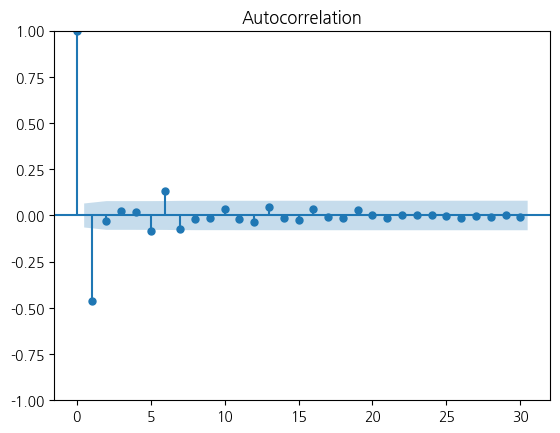

In [22]:
# ACF,PACF를 통해 p,q 후보 추출
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plot_acf(sale['diff'].dropna(), lags=30)

# 저장
plt.savefig('/content/drive/MyDrive/경경데/ACF.png', dpi=300, bbox_inches='tight')
plt.show()


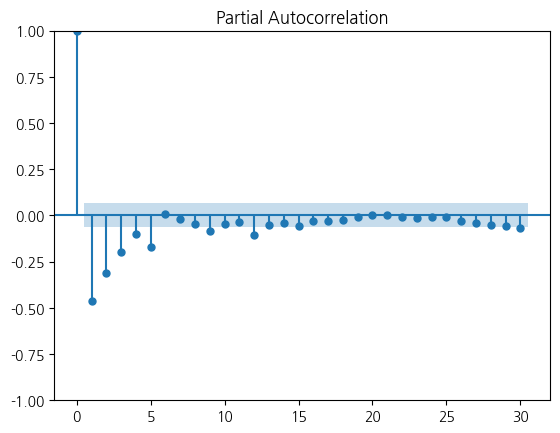

In [23]:
#PACF를 통해 p,q 후보 추출

plot_pacf(sale['diff'].dropna(), lags=30)
# 저장
plt.savefig('/content/drive/MyDrive/경경데/PACF.png', dpi=300, bbox_inches='tight')
plt.show()

In [132]:
sale.head()

,round,total_sale,first_num,first_amount,carry_over,fourth_fifth_num,log_total_sale,cf_total_sale,log_cf_total_sale,year_month,CCSI,diff
date,,,,,,,,,,,,
2007-12-15,263.0,3.967713e+10,6.0,1551704900,0.0,914793,24.404041,3.967713e+10,24.404041,2007-12,NaN,NaN
2007-12-22,264.0,3.978318e+10,7.0,1344889200,0.0,890339,24.406710,3.978318e+10,24.406710,2007-12,NaN,1.060500e+08
2007-12-29,265.0,4.091392e+10,8.0,1200838575,0.0,942122,24.434736,4.091392e+10,24.434736,2007-12,NaN,1.130744e+09
2008-01-05,266.0,4.193707e+10,3.0,3207211700,0.0,1045315,24.459436,4.193707e+10,24.459436,2008-01,NaN,1.023145e+09
2008-01-12,267.0,4.183585e+10,3.0,3257663300,0.0,981023,24.457020,4.183585e+10,24.457020,2008-01,NaN,-1.012140e+08


In [17]:
# ARIMA 모델 상에서의 최적 p,q 추정
from statsmodels.tsa.arima.model import ARIMA

y = sale['total_sale'].dropna()

# y = sale['total_sale'].dropna()  # 결측값 제거

best_aic = float('inf')
best_order = None
best_model = None

for p in range(0, 6):
    for q in range(0, 3):
        try:
            model = ARIMA(y, order=(p, 1, q))
            result = model.fit()

            # 수렴 여부 확인
            if not result.mle_retvals.get('converged', False):
                print(f'❌ 수렴 실패: ARIMA({p},1,{q}) → AIC: {result.aic:.2f}')
                continue

            print(f'ARIMA({p},1,{q}) → AIC: {result.aic:.2f}, BIC: {result.bic:.2f}')

            if result.aic < best_aic:
                best_aic = result.aic
                best_order = (p, 1, q)
                best_model = result

        except Exception as e:
            print(f'ARIMA({p},1,{q}) → 오류: {e}')

print(f"\n✅ 최적 모델: ARIMA{best_order} (AIC: {best_aic:.2f})")

ARIMA(0,1,0) → AIC: 43108.22, BIC: 43113.04
ARIMA(0,1,1) → AIC: 42772.48, BIC: 42782.11
ARIMA(0,1,2) → AIC: 42773.34, BIC: 42787.78
ARIMA(1,1,0) → AIC: 42908.63, BIC: 42918.26
ARIMA(1,1,1) → AIC: 42772.96, BIC: 42787.41
ARIMA(1,1,2) → AIC: 42775.34, BIC: 42794.59
ARIMA(2,1,0) → AIC: 42828.74, BIC: 42843.18
ARIMA(2,1,1) → AIC: 42774.97, BIC: 42794.22
ARIMA(2,1,2) → AIC: 42777.36, BIC: 42801.42
ARIMA(3,1,0) → AIC: 42800.74, BIC: 42820.00


KeyboardInterrupt: 

### 최적 p,d,q 함수 설정

In [18]:
# 최적 p,d,q 탐색 함수
def search_best_sarimax(y, exog, d=1, max_p=5, max_q=2):
    """
    외생변수(exog)를 포함한 SARIMAX 모델에서 수렴된 최적의 (p,d,q)를 탐색
    """
    best_aic = float('inf')
    best_order = None
    best_result = None

    for p in range(max_p + 1):
        for q in range(max_q + 1):
            try:
                model = SARIMAX(y, exog=exog, order=(p, d, q))
                result = model.fit(disp=False)

                # ✅ 수렴하지 않은 모델은 무시
                if not result.mle_retvals.get("converged", False):
                    print(f"❌ 수렴 실패: ({p},{d},{q})")
                    continue

                # ✅ 수렴했으며 AIC가 가장 낮은 모델 선택
                if result.aic < best_aic:
                    best_aic = result.aic
                    best_order = (p, d, q)
                    best_result = result

            except Exception as e:
                print(f"오류 발생: ({p},{d},{q}) → {e}")
                continue

    if best_result is None:
        raise ValueError("수렴에 성공한 SARIMAX 모델이 없습니다.")

    return best_order

### 외생변수간 상관관계 확인

✅ y와 외생변수 간 상관계수:
fourth_fifth_num_lag1    0.972853
first_num_lag1           0.512917
first_amount_lag1       -0.041712
CCSI                    -0.249720
Name: log_cf_total_sale, dtype: float64


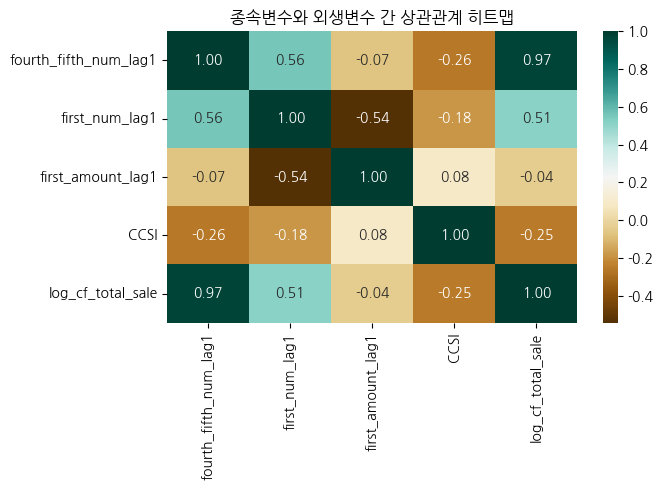

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 외생변수 및 종속변수 선택
X_cols = ['fourth_fifth_num_lag1', 'first_num_lag1', 'first_amount_lag1', 'CCSI']
y_col = 'log_cf_total_sale'

# X와 y 합치기
corr_df = sale[X_cols + [y_col]].dropna()  # 결측값 제거

# 상관계수 출력
correlations = corr_df.corr()[y_col].drop(y_col)
print("✅ y와 외생변수 간 상관계수:")
print(correlations.sort_values(ascending=False))

# 히트맵 시각화
plt.figure(figsize=(7, 5))
sns.heatmap(corr_df.corr(), annot=True, cmap='BrBG', fmt=".2f")
plt.title("종속변수와 외생변수 간 상관관계 히트맵")
plt.tight_layout()



# 저장
plt.savefig('/content/drive/MyDrive/경경데/상관관계 히트맵.png', dpi=300, bbox_inches='tight')
plt.show()

### 실험1 : 이월여부의 판매효과

In [27]:
sale.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 911 entries, 2007-12-15 to 2025-05-24
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   round              911 non-null    float64
 1   total_sale         911 non-null    float64
 2   first_num          911 non-null    float64
 3   first_amount       911 non-null    int64  
 4   carry_over         911 non-null    float64
 5   fourth_fifth_num   911 non-null    int64  
 6   log_total_sale     911 non-null    float64
 7   cf_total_sale      911 non-null    float64
 8   log_cf_total_sale  911 non-null    float64
 9   year_month         911 non-null    object 
 10  CCSI               882 non-null    float64
 11  diff               910 non-null    float64
dtypes: float64(9), int64(2), object(1)
memory usage: 92.5+ KB


In [28]:
# 이월여부
from statsmodels.tsa.statespace.sarimax import SARIMAX

y = sale['total_sale']
X = sale[['carry_over']] # 외생변수는 반드시 2차원 DataFrame

# 최적 (p,d,q) 찾기
best_order = search_best_sarimax(y, X)

# ARIMAX 모델 학습
model = SARIMAX(y, exog=X, order = best_order)
result = model.fit()

# 결과 요약
print(result.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  

                               SARIMAX Results                                
Dep. Variable:             total_sale   No. Observations:                  911
Model:               SARIMAX(4, 1, 2)   Log Likelihood              -21043.000
Date:                Wed, 04 Jun 2025   AIC                          42102.000
Time:                        15:56:20   BIC                          42140.507
Sample:                    12-15-2007   HQIC                         42116.702
                         - 05-24-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
carry_over   4.41e+10   1.07e-10   4.13e+20      0.000    4.41e+10    4.41e+10
ar.L1         -0.2712      0.236     -1.147      0.251      -0.735       0.192
ar.L2          0.4269      0.098      4.358      0.0

In [29]:
# 이월여부 + 로그변환
from statsmodels.tsa.statespace.sarimax import SARIMAX

y = sale['log_total_sale']
X = sale[['carry_over']]  # 외생변수는 반드시 2차원 DataFrame

# 최적 (p,d,q) 찾기
best_order = search_best_sarimax(y, X)

# ARIMAX 모델 학습
model = SARIMAX(y, exog=X, order = best_order)
result = model.fit()

# 결과 요약
print(result.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  

❌ 수렴 실패: (2,1,2)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting

❌ 수렴 실패: (3,1,2)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  

❌ 수렴 실패: (4,1,2)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT 

❌ 수렴 실패: (5,1,1)


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)


❌ 수렴 실패: (5,1,2)
                               SARIMAX Results                                
Dep. Variable:         log_total_sale   No. Observations:                  911
Model:               SARIMAX(0, 1, 1)   Log Likelihood                1902.816
Date:                Wed, 04 Jun 2025   AIC                          -3799.632
Time:                        15:57:14   BIC                          -3785.192
Sample:                    12-15-2007   HQIC                         -3794.119
                         - 05-24-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
carry_over     0.6375      0.002    267.837      0.000       0.633       0.642
ma.L1         -0.4938      0.019    -26.121      0.000      -0.531      -0.457
sigma2         0.0009   1.43e-05   

### 실험2

In [30]:
# 1등 당첨자수에 따른 판매효과
from statsmodels.tsa.statespace.sarimax import SARIMAX

sale['first_num_lag1'] = sale['first_num'].shift(1)

# 결측 제거 (첫 행 1개)
model_df = sale[['cf_total_sale', 'first_num_lag1']].dropna()

# 종속변수와 외생변수 분리
y = model_df['cf_total_sale']
X = model_df[['first_num_lag1']]

# 최적 (p,d,q) 찾기
best_order = search_best_sarimax(y, X)

# ARIMAX 모델 학습
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(y, exog=X, order=best_order)
result = model.fit()
print(result.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  

                               SARIMAX Results                                
Dep. Variable:          cf_total_sale   No. Observations:                  910
Model:               SARIMAX(4, 1, 2)   Log Likelihood              -20862.006
Date:                Wed, 04 Jun 2025   AIC                          41740.011
Time:                        15:57:43   BIC                          41778.510
Sample:                    12-22-2007   HQIC                         41754.711
                         - 05-24-2025                                         
Covariance Type:                  opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
first_num_lag1 -1.199e+07   1.78e-09  -6.75e+15      0.000    -1.2e+07    -1.2e+07
ar.L1             -0.2457      0.202     -1.216      0.224      -0.642       0.150
ar.L2              0.5381      0.127

In [31]:
# 1등 당첨자수에 따른 판매효과
from statsmodels.tsa.statespace.sarimax import SARIMAX

sale['first_num_lag1'] = sale['first_num'].shift(1)

# 결측 제거 (첫 행 1개)
model_df = sale[['log_cf_total_sale', 'first_num_lag1']].dropna()

# 종속변수와 외생변수 분리
y = model_df['log_cf_total_sale']
X = model_df[['first_num_lag1']]

# 최적 (p,d,q) 찾기
best_order = search_best_sarimax(y, X)

# ARIMAX 모델 학습
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(y, exog=X, order=best_order)
result = model.fit()
print(result.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT 

❌ 수렴 실패: (0,1,0)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  

❌ 수렴 실패: (2,1,0)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)


❌ 수렴 실패: (2,1,2)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  

❌ 수렴 실패: (4,1,0)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency inf

                               SARIMAX Results                                
Dep. Variable:      log_cf_total_sale   No. Observations:                  910
Model:               SARIMAX(2, 1, 1)   Log Likelihood                1995.904
Date:                Wed, 04 Jun 2025   AIC                          -3981.809
Time:                        15:58:16   BIC                          -3957.747
Sample:                    12-22-2007   HQIC                         -3972.621
                         - 05-24-2025                                         
Covariance Type:                  opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
first_num_lag1 -4.927e-05      0.000     -0.269      0.788      -0.000       0.000
ar.L1             -0.1326      0.115     -1.153      0.249      -0.358       0.093
ar.L2             -0.1398      0.050

### 실험 3

In [20]:
# 1등 당첨금액에 따른 판매효과
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

sale['first_amount_lag1'] = sale['first_amount'].shift(1)
sale['first_amount_lag1_scaled'] = scaler.fit_transform(sale[['first_amount_lag1']])

# 결측 제거 (첫 행 1개)
model_df = sale[['cf_total_sale', 'first_amount_lag1_scaled']].dropna()

# 종속변수와 외생변수 분리
y = model_df['cf_total_sale']
X = model_df[['first_amount_lag1_scaled']]

# 최적 (p,d,q) 찾기
best_order = search_best_sarimax(y, X)

# ARIMAX 모델 학습
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(y, exog=X, order=best_order)
result = model.fit()
print(result.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

                               SARIMAX Results                                
Dep. Variable:          cf_total_sale   No. Observations:                  910
Model:               SARIMAX(4, 1, 2)   Log Likelihood              -20859.764
Date:                Thu, 05 Jun 2025   AIC                          41735.528
Time:                        01:59:27   BIC                          41774.026
Sample:                             0   HQIC                         41750.227
                                - 910                                         
Covariance Type:                  opg                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
first_amount_lag1_scaled  1.339e+08   1.04e-10   1.29e+18      0.000    1.34e+08    1.34e+08
ar.L1                       -0.2250      0.224     -1.004      0.316      -0.664       0.

In [34]:
# 1등 당첨금액에 따른 판매효과
from statsmodels.tsa.statespace.sarimax import SARIMAX

sale['first_amount_lag1'] = sale['first_amount'].shift(1)

# 결측 제거 (첫 행 1개)
model_df = sale[['log_cf_total_sale', 'first_amount_lag1']].dropna()

# 종속변수와 외생변수 분리
y = model_df['log_cf_total_sale']
X = model_df[['first_amount_lag1']]

# 최적 (p,d,q) 찾기
best_order = search_best_sarimax(y, X)

# ARIMAX 모델 학습
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(y, exog=X, order=best_order)
result = model.fit()
print(result.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT 

❌ 수렴 실패: (0,1,0)


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)


❌ 수렴 실패: (0,1,1)


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)


...

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible startin

❌ 수렴 실패: (5,1,1)


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


❌ 수렴 실패: (5,1,2)


ValueError: 수렴에 성공한 SARIMAX 모델이 없습니다.

### 실험 4

In [21]:
# 4,5등 당첨자수에 따른 판매효과
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

sale['fourth_fifth_num_lag1'] = sale['fourth_fifth_num'].shift(1)
sale['fourth_fifth_num_lag1_scaled'] = scaler.fit_transform(sale[['fourth_fifth_num_lag1']])


# 결측 제거 (첫 행 1개)
model_df = sale[['cf_total_sale', 'fourth_fifth_num_lag1_scaled']].dropna()

# 종속변수와 외생변수 분리
y = model_df['cf_total_sale']
X = model_df[['fourth_fifth_num_lag1_scaled']]

# 최적 (p,d,q) 찾기
best_order = search_best_sarimax(y, X)

# ARIMAX 모델 학습
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(y, exog=X, order=best_order)
result = model.fit()
print(result.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot

                               SARIMAX Results                                
Dep. Variable:          cf_total_sale   No. Observations:                  910
Model:               SARIMAX(4, 1, 2)   Log Likelihood              -20864.677
Date:                Thu, 05 Jun 2025   AIC                          41745.353
Time:                        02:09:51   BIC                          41783.852
Sample:                             0   HQIC                         41760.053
                                - 910                                         
Covariance Type:                  opg                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
fourth_fifth_num_lag1_scaled -1.102e+09   1.49e-10  -7.39e+18      0.000    -1.1e+09    -1.1e+09
ar.L1                           -0.2097      0.262     -0.799      0.424     

In [36]:
# 4,5등 당첨자수에 따른 판매효과
from statsmodels.tsa.statespace.sarimax import SARIMAX

sale['fourth_fifth_num_lag1'] = sale['fourth_fifth_num'].shift(1)

# 결측 제거 (첫 행 1개)
model_df = sale[['log_cf_total_sale', 'fourth_fifth_num_lag1_scaled']].dropna()
print(model_df.info())

# 종속변수와 외생변수 분리
y = model_df['log_cf_total_sale']
X = model_df[['fourth_fifth_num_lag1_scaled']]

# 최적 (p,d,q) 찾기
best_order = search_best_sarimax(y, X)

# ARIMAX 모델 학습
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(y, exog=X, order=best_order)
result = model.fit()
print(result.summary())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 910 entries, 2007-12-22 to 2025-05-24
Data columns (total 2 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   log_cf_total_sale             910 non-null    float64
 1   fourth_fifth_num_lag1_scaled  910 non-null    float64
dtypes: float64(2)
memory usage: 21.3 KB
None


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  

❌ 수렴 실패: (4,1,1)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood

❌ 수렴 실패: (4,1,2)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting

❌ 수렴 실패: (5,1,2)
                               SARIMAX Results                                
Dep. Variable:      log_cf_total_sale   No. Observations:                  910
Model:               SARIMAX(2, 1, 1)   Log Likelihood                1998.556
Date:                Wed, 04 Jun 2025   AIC                          -3987.111
Time:                        16:03:24   BIC                          -3963.049
Sample:                    12-22-2007   HQIC                         -3977.924
                         - 05-24-2025                                         
Covariance Type:                  opg                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
fourth_fifth_num_lag1_scaled     0.0104      0.003      3.693      0.000       0.005       0.016
ar.L1                           -0.1694      0.111     -1.52

### 실험 5

In [37]:
# CCSI에 따른 판매효과 분석
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 결측 제거 (첫 행 1개)
model_df = sale[['cf_total_sale', 'CCSI']].dropna()

# 종속변수와 외생변수 분리
y = model_df['cf_total_sale']
X = model_df[['CCSI']]

# 최적 (p,d,q) 찾기
best_order = search_best_sarimax(y, X)

# ARIMAX 모델 학습
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(y, exog=X, order=best_order)
result = model.fit()
print(result.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  

                               SARIMAX Results                                
Dep. Variable:          cf_total_sale   No. Observations:                  882
Model:               SARIMAX(3, 1, 0)   Log Likelihood              -20225.904
Date:                Wed, 04 Jun 2025   AIC                          40461.808
Time:                        16:07:21   BIC                          40485.713
Sample:                    07-05-2008   HQIC                         40470.949
                         - 05-24-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
CCSI        1.705e+07   9.36e-12   1.82e+18      0.000    1.71e+07    1.71e+07
ar.L1         -0.3872      0.012    -33.115      0.000      -0.410      -0.364
ar.L2         -0.2394      0.014    -16.633      0.0

In [157]:
# CCSI에 따른 판매효과 분석
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 결측 제거 (첫 행 1개)
model_df = sale[['log_cf_total_sale', 'CCSI']].dropna()

# 종속변수와 외생변수 분리
y = model_df['log_cf_total_sale']
X = model_df[['CCSI']]

# 최적 (p,d,q) 찾기
best_order = search_best_sarimax(y, X)

# ARIMAX 모델 학습
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(y, exog=X, order=best_order)
result = model.fit()
print(result.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:      log_cf_total_sale   No. Observations:                  882
Model:               SARIMAX(2, 1, 0)   Log Likelihood                1932.212
Date:                Wed, 04 Jun 2025   AIC                          -3856.425
Time:                        07:08:38   BIC                          -3837.300
Sample:                    07-05-2008   HQIC                         -3849.112
                         - 05-24-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
CCSI           0.0002      0.000      0.433      0.665      -0.001       0.001
ar.L1         -0.4022      0.025    -16.317      0.000      -0.451      -0.354
ar.L2         -0.2268      0.029     -7.900      0.0

### 판매금액 예측 모델 구현

In [59]:
# 경제적 상황에 따른 판매효과
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import StandardScaler

# 시점 변화
# 1. 전 회차의 1등 당첨자 수를 외생변수로 사용 (lag 처리)
sale['first_num_lag1'] = sale['first_num'].shift(1)
sale['first_amount_lag1'] =sale['first_amount'].shift(1)
sale['fourth_fifth_num_lag1'] = sale['fourth_fifth_num'].shift(1)

# 정규화
scaler = StandardScaler()
sale['CCSI_scaled'] = scaler.fit_transform(sale[['CCSI']])
sale['first_num_lag1_scaled'] = scaler.fit_transform(sale[['first_num_lag1']])
sale['fourth_fifth_num_lag1_scaled'] = scaler.fit_transform(sale[['fourth_fifth_num_lag1']])

# 결측 제거 (첫 행 1개)
model_df = sale[['round','cf_total_sale', 'CCSI_scaled','first_num_lag1','first_amount_lag1','fourth_fifth_num_lag1','first_num_lag1_scaled','fourth_fifth_num_lag1_scaled']].dropna()

In [46]:
# 다중공선성 확인
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# X: 외생변수 DataFrame
X = model_df[['CCSI_scaled', 'first_num_lag1_scaled', 'fourth_fifth_num_lag1_scaled']]

# VIF 계산
vif_df = pd.DataFrame()
vif_df["feature"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_df)


                        feature       VIF
0                   CCSI_scaled  1.072819
1         first_num_lag1_scaled  1.451313
2  fourth_fifth_num_lag1_scaled  1.502128


In [54]:
# 종속변수와 외생변수 분리
y = model_df['cf_total_sale']
X = model_df[['CCSI_scaled', 'first_num_lag1_scaled', 'fourth_fifth_num_lag1_scaled']]

# 최적 (p,d,q) 찾기
best_order = search_best_sarimax(y, X)

# ARIMAX 모델 학습
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(y, exog=X, order=best_order)
result = model.fit()
print(result.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  

                               SARIMAX Results                                
Dep. Variable:          cf_total_sale   No. Observations:                  882
Model:               SARIMAX(3, 1, 0)   Log Likelihood              -20230.049
Date:                Wed, 04 Jun 2025   AIC                          40474.097
Time:                        16:29:52   BIC                          40507.565
Sample:                    07-05-2008   HQIC                         40486.895
                         - 05-24-2025                                         
Covariance Type:                  opg                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
CCSI_scaled                   1.556e+08   1.99e-13   7.82e+20      0.000    1.56e+08    1.56e+08
first_num_lag1_scaled         2.894e+06    5.2e-13   5.57e+18      0.000    2

In [55]:
#RMSE 계산코드

from sklearn.metrics import mean_squared_error
import numpy as np

# 평균 판매금액
mean_sale = model_df['cf_total_sale'].mean()

# 예측값
y_pred = result.fittedvalues  # 또는 result.predict()


# RMSE 계산
rmse = np.sqrt(mean_squared_error(y, y_pred))
print("mean_total_sale:", mean_sale)
print("RMSE:", rmse)


mean_total_sale: 74662440489.91121
RMSE: 2679943599.72072


In [56]:
from sklearn.metrics import r2_score

r2 = r2_score(y, y_pred)
print("R² (설명력):", r2)

R² (설명력): 0.9868426637892901


### 동적 예측

In [57]:
sale.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 911 entries, 2007-12-15 to 2025-05-24
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   round                         911 non-null    float64
 1   total_sale                    911 non-null    float64
 2   first_num                     911 non-null    float64
 3   first_amount                  911 non-null    int64  
 4   carry_over                    911 non-null    float64
 5   fourth_fifth_num              911 non-null    int64  
 6   log_total_sale                911 non-null    float64
 7   cf_total_sale                 911 non-null    float64
 8   log_cf_total_sale             911 non-null    float64
 9   year_month                    911 non-null    object 
 10  CCSI                          882 non-null    float64
 11  diff                          910 non-null    float64
 12  first_num_lag1                910 non-null   

In [60]:
from datetime import timedelta

# 회차를 인덱스로 갖고 있다고 가정 (model_df.index 또는 model_df['round'])
# 또는 아래처럼 회차 정보가 있다면 직접 생성해도 됨
start_round = model_df['round'].min()
end_round = model_df['round'].max()

# 마지막 회차 날짜 (1173회차 = 2025-05-24)
last_round = 1173
last_round_date = pd.to_datetime('2025-05-24')

# 각 회차별 날짜 계산
model_df['draw_date'] = model_df['round'].apply(
    lambda x: last_round_date - timedelta(weeks=(last_round - x))
)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 882 entries, 2008-07-05 to 2025-05-24
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   round                         882 non-null    float64       
 1   cf_total_sale                 882 non-null    float64       
 2   CCSI_scaled                   882 non-null    float64       
 3   first_num_lag1                882 non-null    float64       
 4   first_amount_lag1             882 non-null    float64       
 5   fourth_fifth_num_lag1         882 non-null    float64       
 6   first_num_lag1_scaled         882 non-null    float64       
 7   fourth_fifth_num_lag1_scaled  882 non-null    float64       
 8   draw_date                     882 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(8)
memory usage: 68.9 KB
None


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SAT will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                      cf_total_sale   No. Observations:                  882
Model:             SARIMAX(3, 1, 0)x(1, 1, 0, 52)   Log Likelihood              -17794.299
Date:                            Wed, 04 Jun 2025   AIC                          35604.598
Time:                                    16:36:00   BIC                          35641.810
Sample:                                07-05-2008   HQIC                         35618.915
                                     - 05-24-2025                                         
Covariance Type:                              opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
CCSI_scaled       -8.629e+07      1e-12   -8.6e+19      0.000   -8.63e+07   -8.63e+07
first_num_lag1

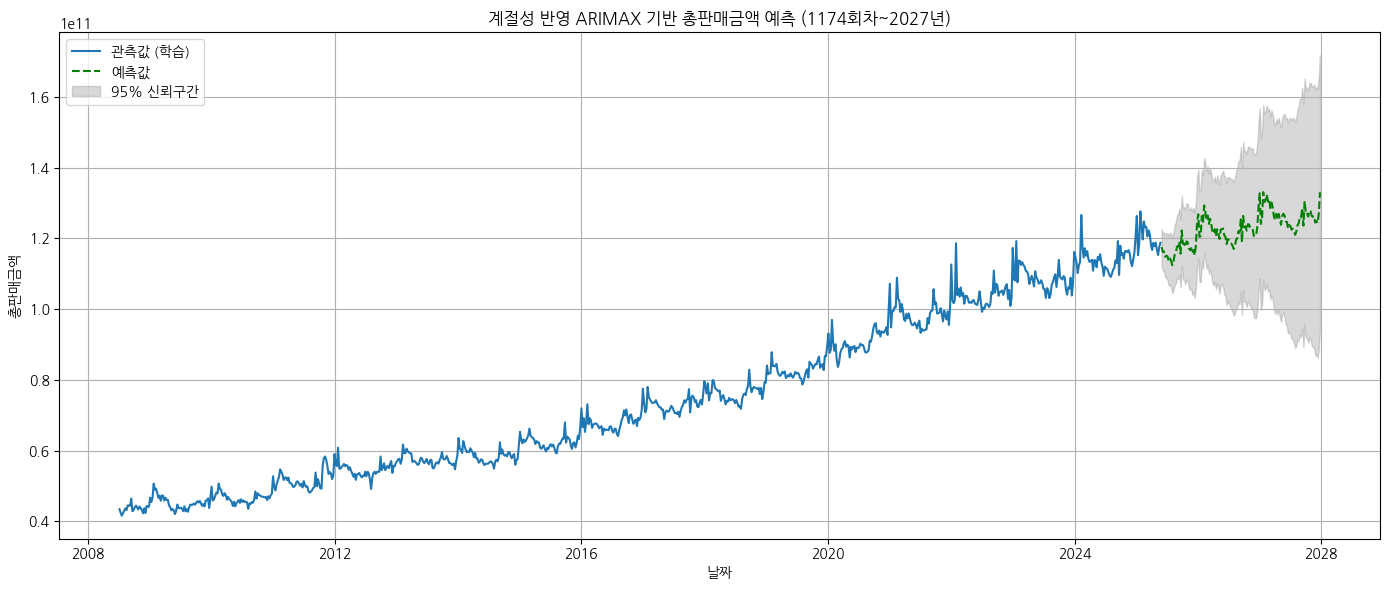

In [62]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# -------------------------
# 1. 데이터 준비
# -------------------------
# 종속변수와 외생변수 분리
y = model_df['cf_total_sale']
X = model_df[['CCSI_scaled', 'first_num_lag1', 'first_amount_lag1']]

model_df['round'] = sale['round']

print(model_df.info())
# 인덱스가 날짜여야 함 (주간 시계열)
model_df.index = pd.to_datetime(model_df['draw_date'])  # 'draw_date'는 추첨일자 컬럼
y.index = model_df.index
X.index = model_df.index

# -------------------------
# 2. SARIMAX 모델 학습 (계절성 포함)
# -------------------------
model = SARIMAX(
    y,
    exog=X,
    order=(3, 1, 0),
    seasonal_order=(1, 1, 0, 52),  # 52주 주기 계절성
    enforce_stationarity=False,
    enforce_invertibility=False
)
result = model.fit()
print(result.summary())

# -------------------------
# 3. 미래 외생변수 생성 (1174회차 ~ 2027-12-31까지)
# -------------------------
last_date = pd.to_datetime("2025-05-24")
end_date = pd.to_datetime("2027-12-31")
n_periods = (end_date - last_date).days // 7

# 미래 날짜 생성
future_dates = [last_date + timedelta(weeks=i+1) for i in range(n_periods)]

# 외생변수 시나리오 (간단하게 평균값 사용)
X_future = pd.DataFrame({
    'CCSI_scaled': [X['CCSI_scaled'].mean()] * n_periods,
    'first_num_lag1': [X['first_num_lag1'].mean()] * n_periods,
    'first_amount_lag1': [X['first_amount_lag1'].mean()] * n_periods
}, index=future_dates)

# -------------------------
# 4. 예측 수행
# -------------------------
forecast_result = result.get_forecast(steps=n_periods, exog=X_future)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

# -------------------------
# 5. 결과 정리
# -------------------------
forecast_df = pd.DataFrame({
    '회차': range(1174, 1174 + n_periods),
    '예측일': future_dates,
    '예측_총판매금액': forecast_mean.values,
    '신뢰구간_하한': forecast_ci.iloc[:, 0].values,
    '신뢰구간_상한': forecast_ci.iloc[:, 1].values
})

# -------------------------
# 6. 시각화
# -------------------------
plt.figure(figsize=(14,6))
plt.plot(y.index, y, label='관측값 (학습)')
plt.plot(forecast_df['예측일'], forecast_df['예측_총판매금액'], label='예측값', linestyle='--', color = 'green')
plt.fill_between(forecast_df['예측일'], forecast_df['신뢰구간_하한'], forecast_df['신뢰구간_상한'], color='gray', alpha=0.3, label='95% 신뢰구간')
plt.title('계절성 반영 ARIMAX 기반 총판매금액 예측 (1174회차~2027년)')
plt.xlabel('날짜')
plt.ylabel('총판매금액')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


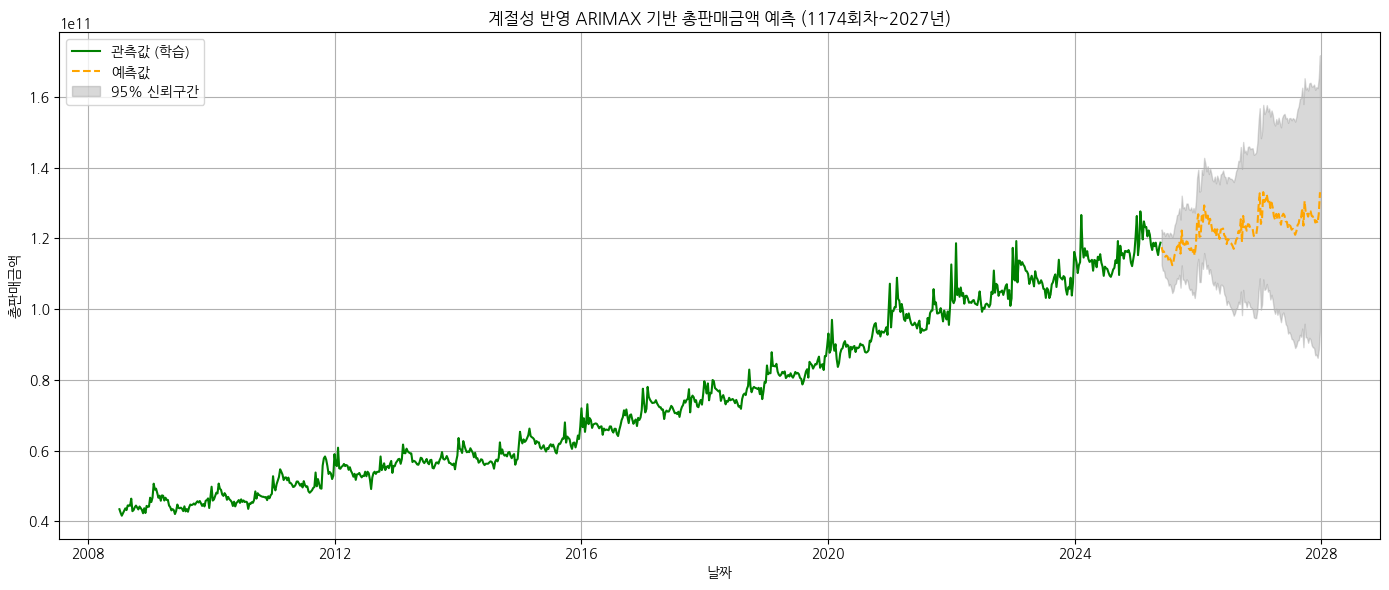

In [64]:
plt.figure(figsize=(14,6))
plt.plot(y.index, y, label='관측값 (학습)', color='green')
plt.plot(forecast_df['예측일'], forecast_df['예측_총판매금액'], label='예측값', linestyle='--', color='orange')
plt.fill_between(forecast_df['예측일'], forecast_df['신뢰구간_하한'], forecast_df['신뢰구간_상한'], color='gray', alpha=0.3, label='95% 신뢰구간')
plt.title('계절성 반영 ARIMAX 기반 총판매금액 예측 (1174회차~2027년)')
plt.xlabel('날짜')
plt.ylabel('총판매금액')
plt.legend()
plt.grid(True)
plt.tight_layout()

# 저장
plt.savefig('/content/drive/MyDrive/경경데/시계열 예측.png', dpi=300, bbox_inches='tight')
plt.show()

In [184]:
forecast_df.to_csv("/content/drive/MyDrive/경경데/예측금액.csv", encoding = 'utf-8')

### 예측 결과 분석

In [65]:
import pandas as pd


# 1. 데이터 로딩
forecast_df.columns = [col.strip() for col in forecast_df.columns]
forecast_df['예측일'] = pd.to_datetime(forecast_df['예측일'], errors='coerce')

# 2. 반기별 필터 조건 정의
conditions = {
    '2025 하반기': (forecast_df['예측일'] >= '2025-07-01') & (forecast_df['예측일'] <= '2025-12-31'),
    '2026 상반기': (forecast_df['예측일'] >= '2026-01-01') & (forecast_df['예측일'] <= '2026-06-30'),
    '2026 하반기': (forecast_df['예측일'] >= '2026-07-01') & (forecast_df['예측일'] <= '2026-12-31'),
    '2027 상반기': (forecast_df['예측일'] >= '2027-01-01') & (forecast_df['예측일'] <= '2027-06-30'),
    '2027 하반기': (forecast_df['예측일'] >= '2027-07-01') & (forecast_df['예측일'] <= '2027-12-31'),
}

# 3. 총판매금액 및 정부 가용 예산 계산
total_sales_by_period = []
for period, cond in conditions.items():
    total = forecast_df.loc[cond, '예측_총판매금액'].sum()
    budget = total * 0.42
    total_sales_by_period.append({
        '기간': period,
        '총판매금액': total,
        '정부 가용 예산': budget
    })

# 4. 데이터프레임 생성
result_df = pd.DataFrame(total_sales_by_period)
result_df = result_df.set_index('기간')

# 5. 출력
print(result_df)

result_df.to_csv("/content/drive/MyDrive/경경데/정부가용예산.csv", encoding = 'utf-8')

                 총판매금액      정부 가용 예산
기간                                  
2025 하반기  3.040035e+12  1.276815e+12
2026 상반기  3.198760e+12  1.343479e+12
2026 하반기  3.163372e+12  1.328616e+12
2027 상반기  3.314098e+12  1.391921e+12
2027 하반기  3.265233e+12  1.371398e+12


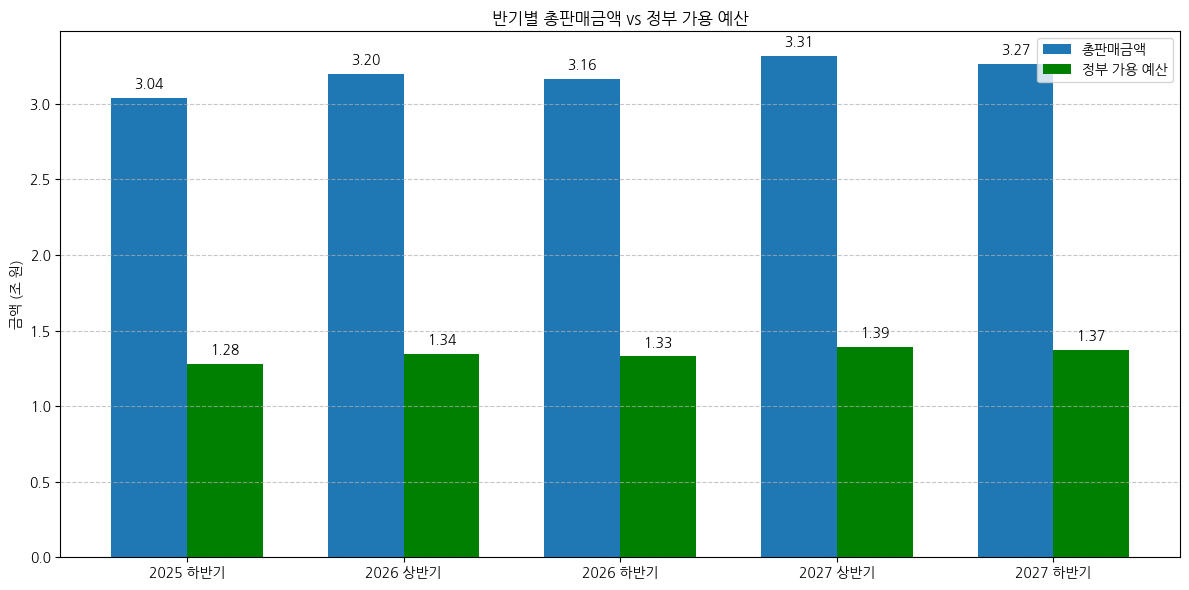

In [73]:
# 시각화
import matplotlib.pyplot as plt
import numpy as np


# x축 라벨
labels = result_df.index.tolist()
x = np.arange(len(labels))  # x 좌표
width = 0.35  # 막대 너비

# 값
total_sales = result_df['총판매금액'].values
gov_budget = result_df['정부 가용 예산'].values

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))
bar1 = ax.bar(x - width/2, total_sales / 1e12, width, label='총판매금액')
bar2 = ax.bar(x + width/2, gov_budget / 1e12, width, label='정부 가용 예산', color='green')

# 라벨 설정
ax.set_ylabel('금액 (조 원)')
ax.set_title('반기별 총판매금액 vs 정부 가용 예산')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

# 바 위에 숫자 표시
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(bar1)
add_labels(bar2)

plt.tight_layout()


# 저장
plt.savefig('/content/drive/MyDrive/경경데/정부예산.png', dpi=300, bbox_inches='tight')
plt.show()


In [88]:
import pandas as pd
import numpy as np

# 1. sale 데이터 불러오기
sale_df = pd.read_csv('/content/drive/MyDrive/경경데/final_cf_sales.csv')
sale_df.drop(['cf_total_sale', '4등 당첨게임 수', '5등 당첨게임 수'], axis=1, inplace=True)
sale_df["log_cf_total_sale"] = np.log(sale_df['cf_total_sale_adjusted'])
sale_df.rename(columns= {'cf_total_sale_adjusted' : 'cf_total_sale'}, inplace=True)
sale_df["date"] = pd.to_datetime(sale_df["date"])

# 2. forecast 데이터 불러오기
forecast_df = pd.read_csv("/content/drive/MyDrive/경경데/forecast_df.csv", encoding='utf-8')
forecast_df["예측일"] = pd.to_datetime(forecast_df["예측일"])

# 3. 2025년 상반기 실제 데이터
mask_sale = (sale_df['date'] >= '2025-01-01') & (sale_df['date'] <= '2025-05-24')
total_sale_early = sale_df.loc[mask_sale, 'cf_total_sale'].sum()

# 4. 2025년 하반기 예측 데이터
mask_forecast = (forecast_df['예측일'] >= '2025-05-25') & (forecast_df['예측일'] <= '2025-12-31')
total_sale_late = forecast_df.loc[mask_forecast, '예측_총판매금액'].sum()

# 5. 2025년 총합
total_2025 = total_sale_early + total_sale_late

# 정부기금
budget_2025 = total_2025 * 0.42

# 법정배분사업
law_budget_2025 = budget_2025 * 0.35

# 공익지원사업
public_budget_2025 = budget_2025 * 0.65

# 6. 출력
print(f"2025년 총 판매금액: {total_2025:,.0f} 원")
print(f"2025년 복권기금예산: {budget_2025:,.0f} 원")
print(f"2025년 법정배분예산: {law_budget_2025:,.0f} 원")
print(f"2025년 공익지원사업예산: {public_budget_2025:,.0f} 원")

2025년 총 판매금액: 6,144,509,218,523 원
2025년 복권기금예산: 2,580,693,871,780 원
2025년 법정배분예산: 903,242,855,123 원
2025년 공익지원사업예산: 1,677,451,016,657 원


In [75]:
forecast_df.to_csv("/content/drive/MyDrive/경경데/forecast_df.csv",encoding='utf-8')

In [92]:
# 2024년 총 판매금액 (정확히 1월 1일 ~ 12월 31일)
mask_2024 = (sale_df['date'] >= '2023-01-01') & (sale_df['date'] <= '2023-12-31')
total_2024 = sale_df.loc[mask_2024, 'cf_total_sale'].sum()

# 정부기금
budget_2024 = total_2024 * 0.42

# 법정배분사업
law_budget_2024 = budget_2024 * 0.35

# 공익지원사업
public_budget_2024 = budget_2024 * 0.65

# 출력
print(f"2024년 총 판매금액: {total_2024:,.0f} 원")
print(f"2024년 복권기금예산: {budget_2024:,.0f} 원")
print(f"2024년 법정배분예산: {law_budget_2024:,.0f} 원")
print(f"2024년 공익지원사업예산: {public_budget_2024:,.0f} 원")

2024년 총 판매금액: 5,648,581,000,000 원
2024년 복권기금예산: 2,372,404,020,000 원
2024년 법정배분예산: 830,341,407,000 원
2024년 공익지원사업예산: 1,542,062,613,000 원
